# 01 — Data Generating Processes and Exploratory Analysis

## Purpose
This notebook generates synthetic VAR datasets under multiple innovation regimes and performs exploratory analysis of the resulting time series and innovation distributions.

## Outputs
- Simulated VAR datasets
- Innovation diagnostic tables
- Time series visualizations
- Innovation distribution diagnostics

## Future Work
- Expand to additional DGP families
- Introduce nonlinear and regime-switching systems

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.utils.seeds import set_seed
from src.experiments.config import ExperimentConfig
from src.experiments.paths import result_dirs
from src.experiments.artifacts import save_table, save_array_npz, save_json, save_current_figure
from src.data.simulation import ( make_stable_var_matrix, generate_multiple_var_datasets,)
from src.innovations.diagnostics import summarize_innovations

set_seed(123)

config = ExperimentConfig()
dirs = result_dirs("01_dgp_eda", test=False)

In [2]:
k = 3
n_obs = 800
burn_in = 100
base_seed = config.seed
dgp_names = config.dgp_names

A = make_stable_var_matrix( k=k, scale=0.45, seed=base_seed,)

Sigma = np.array(
    [
        [1.0, 0.3, 0.1],
        [0.3, 1.0, 0.2],
        [0.1, 0.2, 1.0],
    ]
)

scenario_params = {
    "student_t_df": 3.5,
    "mixture_high_prob": 0.15,
    "mixture_high_scale": 9.0,
    "hetero_base_scale": 0.4,
    "hetero_high_scale": 2.5,
    "hetero_period": 40,
}

print("A:")
print(A)

print("\nSigma:")
print(Sigma)

print("\nScenario parameters:")
scenario_params

A:
[[-0.37465394 -0.1393082   0.48783324]
 [ 0.07347256  0.34855999  0.2185922 ]
 [-0.2410762   0.20527768 -0.11991828]]

Sigma:
[[1.  0.3 0.1]
 [0.3 1.  0.2]
 [0.1 0.2 1. ]]

Scenario parameters:


{'student_t_df': 3.5,
 'mixture_high_prob': 0.15,
 'mixture_high_scale': 9.0,
 'hetero_base_scale': 0.4,
 'hetero_high_scale': 2.5,
 'hetero_period': 40}

In [3]:
datasets = generate_multiple_var_datasets(
    dgp_names=dgp_names,
    n_obs=n_obs,
    burn_in=burn_in,
    A=A,
    Sigma=Sigma,
    base_seed=base_seed,
    **scenario_params,
)

for name, data in datasets.items():

    print(
        name,
        data["y"].shape,
        data["innovations"].shape,
    )

gaussian (800, 3) (800, 3)
student_t (800, 3) (800, 3)
mixture (800, 3) (800, 3)
heteroskedastic (800, 3) (800, 3)


/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/data/simulation.py:47: RuntimeWarning: divide by zero encountered in matmul
  return rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/data/simulation.py:47: RuntimeWarning: overflow encountered in matmul
  return rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/data/simulation.py:47: RuntimeWarning: invalid value encountered in matmul
  return rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/data/simulation.py:66: RuntimeWarning: divide by zero encountered in matmul
  z = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/src/data/simulation.py:66: RuntimeWarning: overflow encountered in matmul
  z = rng.multivariate_normal(
/Users/jonathanma/Desktop/MSEnotes

In [4]:
simulated_dir = ROOT / "data" / "simulated"
simulated_dir.mkdir(
    parents=True,
    exist_ok=True,
)

for name, data in datasets.items():

    save_array_npz(
        simulated_dir / f"{name}_var_dgp.npz",
        y=data["y"],
        innovations=data["innovations"],
        A=data["A"],
        Sigma=data["Sigma"],
    )

print(
    "Saved DGP datasets to:",
    simulated_dir,
)

Saved DGP datasets to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/data/simulated


The plots below show the first simulated series from each DGP. These are not meant to prove misspecification by themselves, but they provide a quick visual check that the generated systems are stable and exhibit different shock behavior.

Saved: raw_dgp_series.png


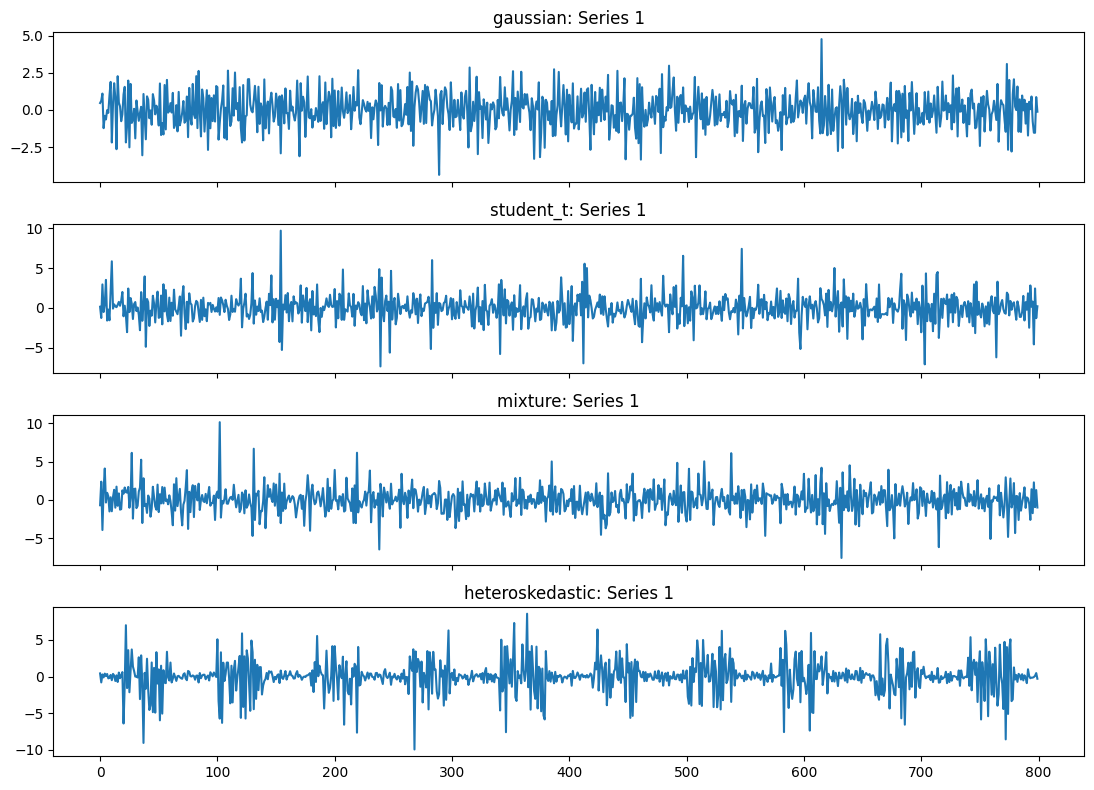

In [5]:
from src.plots.dgp import plot_raw_dgp_series

plot_raw_dgp_series( datasets, variable=0,)
save_current_figure( dirs["figures"] / "raw_dgp_series.png")
print("Saved: raw_dgp_series.png")

Saved: heteroskedastic_all_series.png


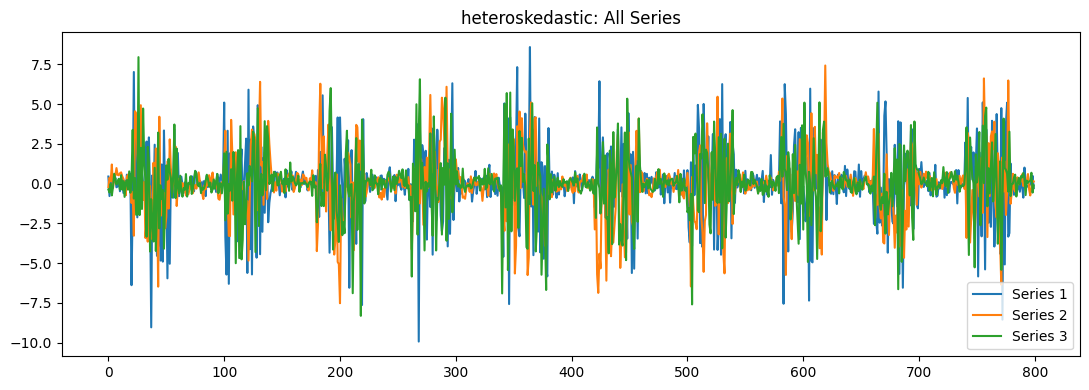

In [6]:
from src.plots.dgp import plot_all_series

name = "heteroskedastic"
y = datasets[name]["y"]
plot_all_series(y=y,title=f"{name}: All Series",)
save_current_figure(dirs["figures"] / f"{name}_all_series.png")
print( f"Saved: {name}_all_series.png")

## Innovation Diagnostics

Because the true innovations are known in simulation, this notebook directly examines the generated innovation distributions.

The Gaussian system should have approximately zero skewness, kurtosis near 3, and relatively large Jarque--Bera p-values. The Student-t, mixture, and heteroskedastic systems are designed to show heavier tails, excess kurtosis, and stronger deviations from Gaussianity.

In [7]:
from src.api.dgp import innovation_diagnostics_table, innovation_diagnostics_summary

diagnostics_df = innovation_diagnostics_table( datasets,)
save_table(diagnostics_df,dirs["tables"] / "innovation_diagnostics.csv",)
diagnostics_df

,dgp,series,mean,std,skewness,kurtosis,excess_kurtosis,jb_stat,jb_pvalue
0,gaussian,1,0.008468,1.002807,-0.053655,3.233904,0.233904,2.069227,3.553637e-01
1,gaussian,2,0.034006,1.001409,0.145381,3.124375,0.124375,3.256888,1.962347e-01
2,gaussian,3,-0.023386,1.029942,0.004482,3.055869,0.055869,0.079564,9.609989e-01
3,student_t,1,0.064999,1.463212,0.284135,8.228185,5.228185,907.928081,7.013296e-198
4,student_t,2,-0.029000,1.421980,-0.431422,7.386799,4.386799,656.035925,3.496302e-143
5,student_t,3,-0.086446,1.496422,0.875465,18.288881,15.288881,7788.964112,0.000000e+00
6,mixture,1,0.002936,1.479811,0.189251,8.884718,5.884718,1141.810327,1.145613e-248
7,mixture,2,0.032182,1.420369,-0.145440,8.348398,5.348398,941.808508,3.082343e-205
8,mixture,3,0.021870,1.438758,-0.247827,7.113787,4.113787,563.209714,5.018391e-123
9,heteroskedastic,1,-0.000719,1.855241,-0.078632,5.615403,2.615403,224.700030,1.610677e-49


In [8]:
summary_df = innovation_diagnostics_summary( diagnostics_df,)
save_table(summary_df,dirs["tables"] / "innovation_diagnostics_summary.csv",)
summary_df

,dgp,skewness,kurtosis,excess_kurtosis,jb_pvalue
0,gaussian,0.032069,3.138049,0.138049,5.041991e-01
1,heteroskedastic,-0.125634,5.597028,2.597028,4.969925e-49
2,mixture,-0.068005,8.115634,5.115634,1.672797e-123
3,student_t,0.242726,11.301288,8.301288,1.165434e-143


Saved: innovation_histograms.png


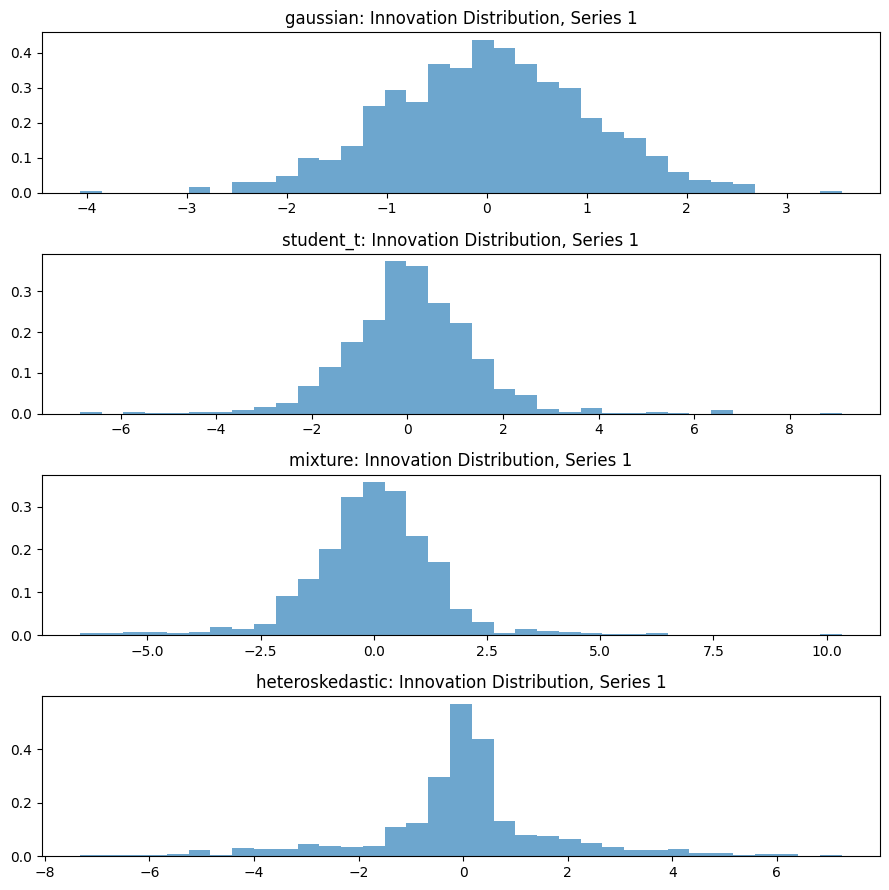

In [9]:
from src.plots.dgp import  plot_innovation_histograms, plot_innovation_qqplots

plot_innovation_histograms(datasets,variable=0,)
save_current_figure( dirs["figures"]  / "innovation_histograms.png")
print("Saved: innovation_histograms.png")

Saved: innovation_qqplots.png


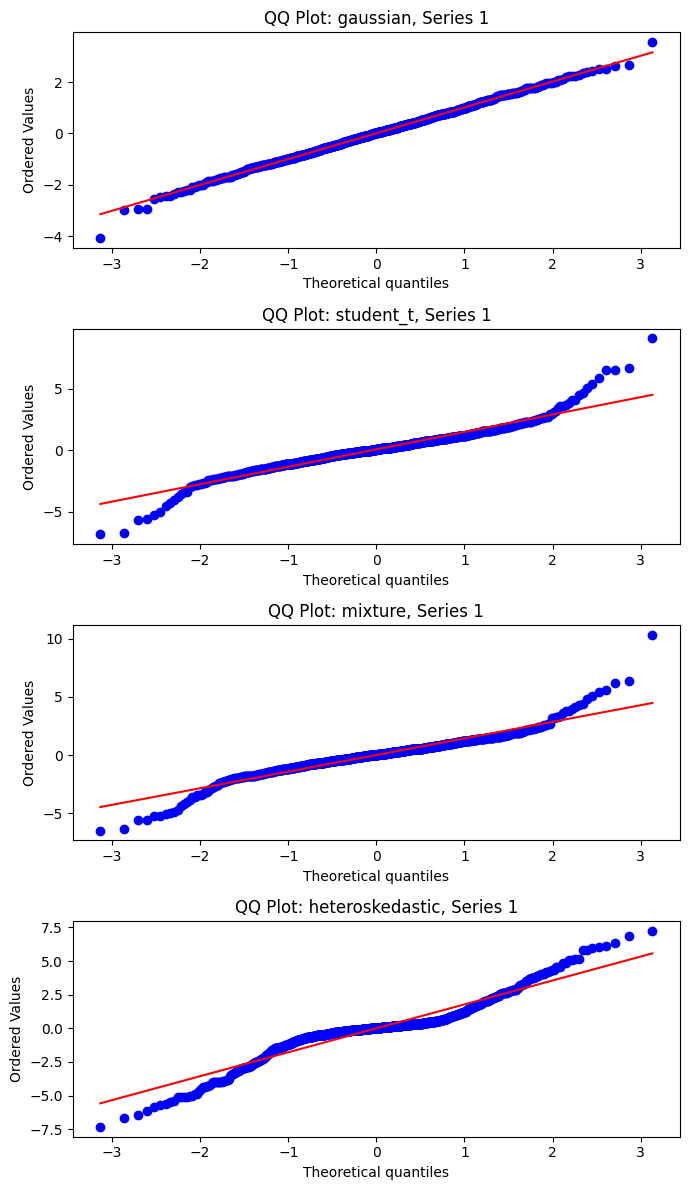

In [10]:
plot_innovation_qqplots(datasets,variable=0,)
save_current_figure(dirs["figures"]/ "innovation_qqplots.png")
print("Saved: innovation_qqplots.png")

In [11]:
save_json(
    {
        "seed": base_seed,
        "n_obs": n_obs,
        "burn_in": burn_in,
        "k": k,
        "dgp_names": dgp_names,
        "scenario_params": scenario_params,
    },
    dirs["logs"] / "dgp_metadata.json",
)

print("01_dgp_eda completed.")

01_dgp_eda completed.


# Discussion and Motivation

The purpose of this notebook was not to build forecasting models yet, but rather to construct controlled stochastic environments where Gaussian innovation assumptions either succeed or fail in identifiable ways. This is important because the broader thesis studies whether flexible innovation models can improve probabilistic forecast calibration under innovation misspecification.

A common stable VAR coefficient matrix was used across all simulated systems so that the autoregressive dynamics remain fixed across experiments. As a result, the primary source of variation between systems is the innovation distribution itself rather than changes in the underlying temporal dynamics. This creates a controlled environment for studying how different innovation structures affect uncertainty behavior and probabilistic forecasting.

The Gaussian DGP behaves approximately as expected under standard assumptions. The innovation distributions exhibit:
- skewness values close to zero,
- kurtosis values near the Gaussian benchmark of 3,
- relatively large Jarque--Bera p-values,
- and QQ plots that remain close to the Gaussian reference line aside from mild tail deviations.

This provides a baseline setting where classical Gaussian innovation assumptions should remain competitive.

In contrast, the Student-$t$, mixture, and heteroskedastic systems exhibit clear departures from Gaussianity. These departures appear through:
- large excess kurtosis,
- substantial tail behavior,
- skewness,
- volatility clustering,
- and extremely small Jarque--Bera p-values.

The Student-$t$ system produces particularly strong heavy-tail behavior, with kurtosis values substantially above the Gaussian benchmark and strong deviations in the QQ plots. The mixture system generates asymmetric tail behavior and occasional extreme shocks arising from the high-variance mixture component. The heteroskedastic system exhibits periods of clustered volatility, where innovation magnitudes vary systematically over time rather than remaining identically distributed.

These systems provide the first concrete examples of environments where Gaussian innovation assumptions are likely to become misspecified. In such settings, classical probabilistic forecasting methods that rely on Gaussian residual assumptions may produce:
- poorly calibrated predictive intervals,
- underestimated tail risk,
- unstable uncertainty estimates,
- and degraded probabilistic forecast quality.

This provides the first motivation for the broader project. Rather than assuming a fixed Gaussian innovation law, the thesis investigates whether more flexible innovation models can better capture the empirical residual structure of stochastic systems and thereby improve probabilistic forecast calibration.

The next stage of the project will fit forecasting models to these simulated systems, extract residual proxies from the fitted models, and evaluate whether diffusion-based innovation modeling improves forecast uncertainty behavior relative to Gaussian and other classical innovation assumptions.